In [10]:
!pip install pandas pydicom -q
!pip install torch torchvision -q
!pip install monai[all] pandas pydicom scikit-learn tqdm -q


[notice] A new release of pip available: 22.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df_orig_train = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')

In [3]:
df_orig_train

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10004044428023505108...,64,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1.2.826.0.1.3680043.8.498.10004684224894397679...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.8.498.10005158603912009425...,58,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1.2.826.0.1.3680043.8.498.10009383108068795488...,71,Male,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.2.826.0.1.3680043.8.498.10012790035410518400...,48,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4400,1.2.826.0.1.3680043.8.498.99915610493694667606...,62,Female,MRI T1post,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4401,1.2.826.0.1.3680043.8.498.99920680741054836990...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4402,1.2.826.0.1.3680043.8.498.99953513260518059135...,44,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4403,1.2.826.0.1.3680043.8.498.99982144859397209076...,58,Female,MRI T2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
for x in df_orig_train.columns:
    print(df_orig_train[x].value_counts())
    print(df_orig_train[x].isnull().sum())
    print('*'*50)

SeriesInstanceUID
1.2.826.0.1.3680043.8.498.99985209798463601651869595532975221005    1
1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647    1
1.2.826.0.1.3680043.8.498.10004684224894397679901841656954650085    1
1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317    1
1.2.826.0.1.3680043.8.498.10009383108068795488741533244914370182    1
                                                                   ..
1.2.826.0.1.3680043.8.498.10023411164590664678534044036963716636    1
1.2.826.0.1.3680043.8.498.10022796280698534221758473208024838831    1
1.2.826.0.1.3680043.8.498.10022688097731894079510930966432818105    1
1.2.826.0.1.3680043.8.498.10021411248005513321236647460239137906    1
1.2.826.0.1.3680043.8.498.10014757658335054766479957992112625961    1
Name: count, Length: 4405, dtype: int64
0
**************************************************
PatientAge
55    127
68    126
65    126
63    125
60    120
     ... 
22     17
21     16
23     13
24     12
18     1

<Axes: xlabel='PatientAge', ylabel='Count'>

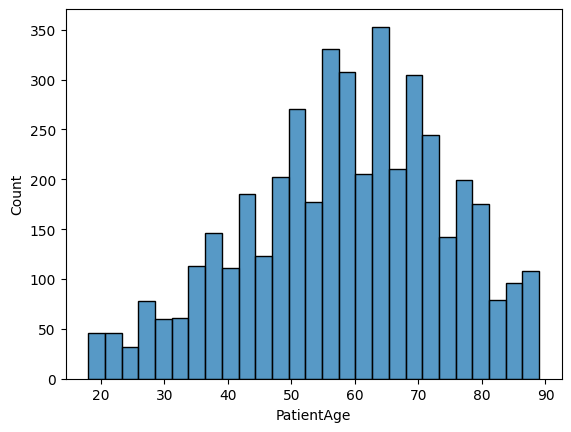

In [4]:
sns.histplot(df_orig_train['PatientAge'])

In [14]:
df_orig_train['Modality'].value_counts()

Modality
CTA           1857
MRA           1256
MRI T2         986
MRI T1post     306
Name: count, dtype: int64

In [20]:
df_orig_train.dtypes

SeriesInstanceUID                             object
PatientAge                                     int64
PatientSex                                    object
Modality                                      object
Left Infraclinoid Internal Carotid Artery      int64
Right Infraclinoid Internal Carotid Artery     int64
Left Supraclinoid Internal Carotid Artery      int64
Right Supraclinoid Internal Carotid Artery     int64
Left Middle Cerebral Artery                    int64
Right Middle Cerebral Artery                   int64
Anterior Communicating Artery                  int64
Left Anterior Cerebral Artery                  int64
Right Anterior Cerebral Artery                 int64
Left Posterior Communicating Artery            int64
Right Posterior Communicating Artery           int64
Basilar Tip                                    int64
Other Posterior Circulation                    int64
Aneurysm Present                               int64
dtype: object

In [26]:
for col in df_orig_train.columns:
    if df_orig_train[col].dtype != 'int64':
        continue
    print(f'{col}: {df_orig_train[col].sum()}')
    print('*'*50)

PatientAge: 257552
**************************************************
Left Infraclinoid Internal Carotid Artery: 79
**************************************************
Right Infraclinoid Internal Carotid Artery: 99
**************************************************
Left Supraclinoid Internal Carotid Artery: 340
**************************************************
Right Supraclinoid Internal Carotid Artery: 282
**************************************************
Left Middle Cerebral Artery: 220
**************************************************
Right Middle Cerebral Artery: 299
**************************************************
Anterior Communicating Artery: 366
**************************************************
Left Anterior Cerebral Artery: 46
**************************************************
Right Anterior Cerebral Artery: 56
**************************************************
Left Posterior Communicating Artery: 87
**************************************************
Right Posterior Commu

In [7]:
import pydicom

# Load the DICOM file
dcm_path = r"C:\Users\solan\Downloads\1.2.826.0.1.3680043.8.498.12512789258062887712849260043950985853.dcm"
ds = pydicom.dcmread(dcm_path)

# Print all metadata tags with their name and value
for elem in ds.iterall():
    print(f"{elem.tag} | {elem.keyword:35} | {repr(elem.value)[:80]}")


(0008,0005) | SpecificCharacterSet                | 'ISO_IR 100'
(0008,0008) | ImageType                           | ['ORIGINAL', 'PRIMARY', 'TOF', 'NONE']
(0008,0016) | SOPClassUID                         | '1.2.840.10008.5.1.4.1.1.4.1'
(0008,0018) | SOPInstanceUID                      | '1.2.826.0.1.3680043.8.498.12512789258062887712849260043950985853'
(0008,0020) | StudyDate                           | '20340307'
(0008,0021) | SeriesDate                          | '20340307'
(0008,0023) | ContentDate                         | '20340307'
(0008,002A) | AcquisitionDateTime                 | '20000101'
(0008,0030) | StudyTime                           | '195521'
(0008,0031) | SeriesTime                          | '200254.15000'
(0008,0033) | ContentTime                         | '200254.15000'
(0008,0050) | AccessionNumber                     | '179'
(0008,0060) | Modality                            | 'MR'
(0008,0070) | Manufacturer                        | 'Philips Medical Systems'
(00

In [2]:
selected_feat = [
    # --- Identifiers ---
    'StudyInstanceUID',
    'SeriesInstanceUID',     # You had this
    'SOPInstanceUID',        # You had this
    'PatientID',

    # --- Patient Info ---
    'PatientAge',
    'PatientSex',
    'PatientWeight',         # You had this
    'PatientSize',           # You had this
    'EthnicGroup',           # You had this
    'SmokingStatus',         # You had this

    # --- Study & Series Descriptors ---
    'Modality',              # You had this
    'StudyDescription',      # You had this
    'SeriesDescription',
    'BodyPartExamined',      # You had this
    'MRAcquisitionType',
    'AngioFlag',

    # --- Image Geometry (CRITICAL for 3D) ---
    'Rows',
    'Columns',
    'PixelSpacing',
    'SliceThickness',
    'SpacingBetweenSlices',
    'ImagePositionPatient',
    'ImageOrientationPatient',

    # --- Acquisition Parameters (Affects image appearance) ---
    'RepetitionTime',
    'EchoTime',
    'FlipAngle',
    'MagneticFieldStrength',
    'Manufacturer',
    'ManufacturerModelName',
    'ScanningSequence',

    # --- Pixel & Windowing Info (For data loading) ---
    'BitsAllocated',
    'BitsStored',
    'PixelRepresentation',
    'WindowCenter',
    'WindowWidth',
    'RescaleIntercept',      # Important to include, will be None for MR but critical for CT
    'RescaleSlope',           # Same as above

    'NumberOfFrames'
]

In [3]:
def extract_dicom_metadata(dcm_path=None, dcm_file=None):
    if dcm_file is None:
        ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
    else:
        ds = dcm_file
    extracted_data = {}

    for tag in selected_feat:
        value = getattr(ds, tag, None)
        if isinstance(value, pydicom.multival.MultiValue):
            value = list(value)
        extracted_data[tag] = value

    return extracted_data

In [4]:
import time

In [8]:
st = time.time()
extract_dicom_metadata(dcm_path)
print(time.time()-st)

0.0021715164184570312


In [9]:
import os

In [10]:
dicom_base_path = r"rsna-intracranial-aneurysm-detection\series"

all_dcm_patth_list =[]
for dirpath, dirnames, filenames in os.walk(dicom_base_path):
    # print(dirpath)
    # print(dirnames)
    # print(filenames)
    # print('*'*50)

    for filename in filenames:
        dcm_path = os.path.join(dirpath, filename)
        all_dcm_patth_list.append(dcm_path)

        

In [11]:
len(all_dcm_patth_list)

1012263

In [23]:
all_f_ext =  [x[-4:] for x in all_dcm_patth_list]

In [24]:
pd.DataFrame(all_f_ext).value_counts()

0   
.dcm    1012263
Name: count, dtype: int64

In [ ]:
metadata_dict_list =[]

for i,x in enumerate(all_dcm_patth_list):
    metadata_dict_list.append(extract_dicom_metadata(x))
    print(f'{i}/1012263')

In [ ]:
pd.DataFrame(metadata_dict_list).isna

In [18]:
metadata_df = pd.DataFrame(metadata_dict_list)

In [19]:
metadata_df

,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,PatientID,PatientAge,PatientSex,PatientWeight,PatientSize,EthnicGroup,SmokingStatus,...,ManufacturerModelName,ScanningSequence,BitsAllocated,BitsStored,PixelRepresentation,WindowCenter,WindowWidth,RescaleIntercept,RescaleSlope,NumberOfFrames
0,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10124807242473374136...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10138383895715496920...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10163629202066490350...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10168500191766317056...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10229246287448303586...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012258,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.95879899683763729350...,af4d0d71-726,None,O,NaN,NaN,None,None,...,SOMATOM Perspective,None,16,16,1,"[80, 250]","[700, 500]",-1024.0,1.0,NaN
1012259,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.97165057246223213383...,af4d0d71-726,None,O,NaN,NaN,None,None,...,SOMATOM Perspective,None,16,16,1,"[80, 250]","[700, 500]",-1024.0,1.0,NaN
1012260,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.98211094707915345512...,af4d0d71-726,None,O,NaN,NaN,None,None,...,SOMATOM Perspective,None,16,16,1,"[80, 250]","[700, 500]",-1024.0,1.0,NaN
1012261,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.98435337720565769477...,af4d0d71-726,None,O,NaN,NaN,None,None,...,SOMATOM Perspective,None,16,16,1,"[80, 250]","[700, 500]",-1024.0,1.0,NaN


In [20]:
metadata_df.to_csv('metadata_df.csv')

In [3]:
metadata_df = pd.read_csv('metadata_df.csv')

C:\Users\solan\AppData\Local\Temp\ipykernel_20392\88472766.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv('metadata_df.csv')


In [5]:
metadata_df.shape

(1012263, 39)

In [4]:
for x in metadata_df.columns:
    print(metadata_df[x].value_counts())
    print(metadata_df[x].isnull().sum())
    print('*'*50)

Unnamed: 0
1012262    1
0          1
1          1
2          1
3          1
          ..
11         1
10         1
9          1
8          1
7          1
Name: count, Length: 1012263, dtype: int64
0
**************************************************
StudyInstanceUID
1.2.826.0.1.3680043.8.498.26875275827756142632463662271305814995    1441
1.2.826.0.1.3680043.8.498.95823759726018881810909243809398453285    1331
1.2.826.0.1.3680043.8.498.54090196673781955332780103653722908665    1314
1.2.826.0.1.3680043.8.498.96493458432292738336891549465693531362    1311
1.2.826.0.1.3680043.8.498.90287698646889729761534522929777327309    1291
                                                                    ... 
1.2.826.0.1.3680043.8.498.10034385894802321175291320093789615030       1
1.2.826.0.1.3680043.8.498.95814811312894040378383764209574694874       1
1.2.826.0.1.3680043.8.498.11035097333885684808818474949068969433       1
1.2.826.0.1.3680043.8.498.11819620448760534150797658408275744970       1
1.2

In [12]:
df_concat = pd.merge(metadata_df,df_orig_train, how='left', on='SeriesInstanceUID')

In [13]:
df_concat

,Unnamed: 0,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,PatientID,PatientAge_x,PatientSex_x,PatientWeight,PatientSize,EthnicGroup,...,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,0,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10124807242473374136...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
1,1,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10138383895715496920...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
2,2,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10163629202066490350...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
3,3,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10168500191766317056...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
4,4,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10229246287448303586...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012258,1012258,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.95879899683763729350...,af4d0d71-726,NaN,O,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,1
1012259,1012259,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.97165057246223213383...,af4d0d71-726,NaN,O,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,1
1012260,1012260,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.98211094707915345512...,af4d0d71-726,NaN,O,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,1
1012261,1012261,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.98435337720565769477...,af4d0d71-726,NaN,O,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,1


In [14]:
df_concat.to_csv('df_concat.csv')

In [16]:
df_concat.shape

(1012263, 56)

In [ ]:
for x in df_concat.columns:
    print(df_concat[x].value_counts())
    print(df_concat[x].isnull().sum())
    print('*'*50)

Unnamed: 0
1012262    1
0          1
1          1
2          1
3          1
          ..
11         1
10         1
9          1
8          1
7          1
Name: count, Length: 1012263, dtype: int64
0
**************************************************
StudyInstanceUID
1.2.826.0.1.3680043.8.498.26875275827756142632463662271305814995    1441
1.2.826.0.1.3680043.8.498.95823759726018881810909243809398453285    1331
1.2.826.0.1.3680043.8.498.54090196673781955332780103653722908665    1314
1.2.826.0.1.3680043.8.498.96493458432292738336891549465693531362    1311
1.2.826.0.1.3680043.8.498.90287698646889729761534522929777327309    1291
                                                                    ... 
1.2.826.0.1.3680043.8.498.10034385894802321175291320093789615030       1
1.2.826.0.1.3680043.8.498.95814811312894040378383764209574694874       1
1.2.826.0.1.3680043.8.498.11035097333885684808818474949068969433       1
1.2.826.0.1.3680043.8.498.11819620448760534150797658408275744970       1
1.2

<Axes: xlabel='Rows', ylabel='Count'>

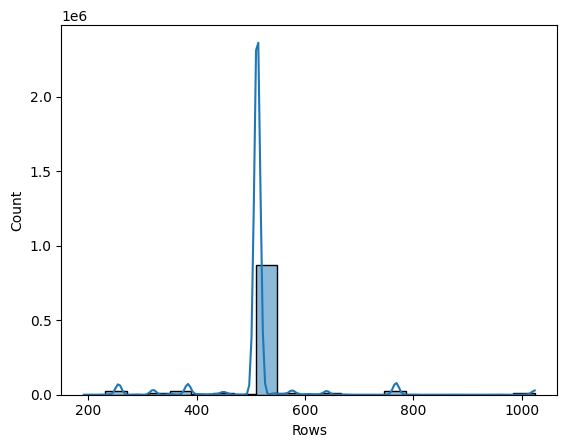

In [19]:
sns.histplot(df_concat['Rows'],kde=True)   

<Axes: xlabel='Columns', ylabel='Count'>

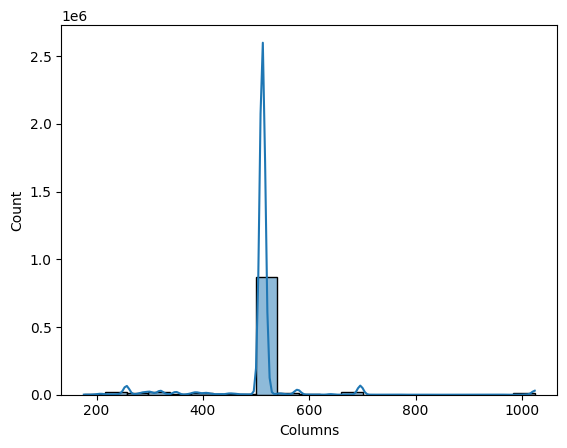

In [20]:
sns.histplot(df_concat['Columns'],kde=True)   

In [5]:
df_concat = pd.read_csv('df_concat.csv')

C:\Users\solan\AppData\Local\Temp\ipykernel_18592\2222918521.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_concat = pd.read_csv('df_concat.csv')


In [6]:
df_ct = df_concat[df_concat['Modality_x'] == 'CT'].copy()
df_mr = df_concat[df_concat['Modality_x'] == 'MR'].copy()

In [6]:
df_ct.shape

(737104, 57)

In [210]:
for x in df_ct.columns:
    print(df_ct[x].value_counts())
    print(f'null count = {df_ct[x].isnull().sum()}')
    print('*'*50)

Unnamed: 0.1
1012246    1
1012245    1
1012244    1
1012243    1
1012242    1
          ..
339        1
338        1
337        1
336        1
335        1
Name: count, Length: 737104, dtype: int64
null count = 0
**************************************************
Unnamed: 0
1012246    1
1012245    1
1012244    1
1012243    1
1012242    1
          ..
339        1
338        1
337        1
336        1
335        1
Name: count, Length: 737104, dtype: int64
null count = 0
**************************************************
StudyInstanceUID
1.2.826.0.1.3680043.8.498.26875275827756142632463662271305814995    1441
1.2.826.0.1.3680043.8.498.95823759726018881810909243809398453285    1331
1.2.826.0.1.3680043.8.498.54090196673781955332780103653722908665    1314
1.2.826.0.1.3680043.8.498.96493458432292738336891549465693531362    1311
1.2.826.0.1.3680043.8.498.90287698646889729761534522929777327309    1291
                                                                    ... 
1.2.826.0.1.3680043

In [7]:
df_mr.shape

(275159, 57)

In [8]:
print(df_ct['RescaleIntercept'].isnull().sum())
df_ct['RescaleSlope'].value_counts()

377593


RescaleSlope
1.0     352138
10.0      7373
Name: count, dtype: int64

In [9]:
print(df_mr['RescaleIntercept'].isnull().sum())
df_mr['RescaleSlope'].value_counts()

235177


RescaleSlope
1.0    39982
Name: count, dtype: int64

In [10]:
df_ct[df_ct['RescaleIntercept'].isnull()]['Modality_y'].value_counts()

Modality_y
CTA    377593
Name: count, dtype: int64

In [ ]:
df_ct

In [4]:
import pydicom
import numpy as np

def robust_hu_conversion(dicom_dataset):
    pixel_array = dicom_dataset.pixel_array
    
    if 'RescaleSlope' in dicom_dataset and 'RescaleIntercept' in dicom_dataset:
        slope = float(dicom_dataset.RescaleSlope)
        intercept = float(dicom_dataset.RescaleIntercept)
        if pixel_array.min() < -500 or pixel_array.min() == -2000:
            return pixel_array
        else:
            return (pixel_array * slope) + intercept
            
    else:
        return pixel_array

In [12]:
base_path = r"rsna-intracranial-aneurysm-detection\series"

In [13]:
import os

In [14]:
dir_path = os.path.join(base_path, df_ct.iloc[0]['SeriesInstanceUID'])
file_dir = [os.path.join(dir_path, f) for f in os.listdir(dir_path)]

In [15]:
pixel_arrays = []
for file_path in file_dir:
    pixel_array = robust_hu_conversion(pydicom.dcmread(file_path))
    pixel_arrays.append(pixel_array)

In [16]:
pixel_arrays

[array([[ -986,  -986,  -987, ...,  -995, -1002, -1005],
        [ -994,  -993,  -992, ..., -1004, -1007, -1008],
        [-1007, -1002,  -999, ..., -1010, -1011, -1007],
        ...,
        [ -913,  -920,  -928, ...,  -933,  -942,  -952],
        [ -895,  -913,  -930, ...,  -930,  -937,  -945],
        [ -861,  -891,  -918, ...,  -933,  -939,  -943]],
       shape=(512, 512), dtype=int16),
 array([[-988, -990, -993, ..., -991, -988, -987],
        [-990, -989, -989, ..., -991, -988, -988],
        [-994, -990, -987, ..., -992, -992, -994],
        ...,
        [-932, -942, -947, ..., -977, -976, -978],
        [-888, -912, -928, ..., -963, -962, -964],
        [-815, -852, -881, ..., -945, -946, -952]],
       shape=(512, 512), dtype=int16),
 array([[-1004, -1003,  -999, ...,  -996,  -992,  -991],
        [-1004, -1003, -1001, ...,  -998,  -993,  -990],
        [-1007, -1005, -1002, ..., -1000,  -995,  -992],
        ...,
        [ -922,  -935,  -943, ...,  -943,  -949,  -951],
     

In [17]:
df_mr.iloc[0]['SeriesInstanceUID']

'1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647'

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def apply_window(hu_image, window_center, window_width):
    """Applies a window to an HU image to make it viewable."""
    min_value = window_center - window_width / 2
    max_value = window_center + window_width / 2
    
    # Clip the image to the window range
    windowed_image = np.clip(hu_image, min_value, max_value)
    
    return windowed_image

def apply_mask(hu_image, min_val, max_val):
    return (hu_image > min_val) & (hu_image < max_val)

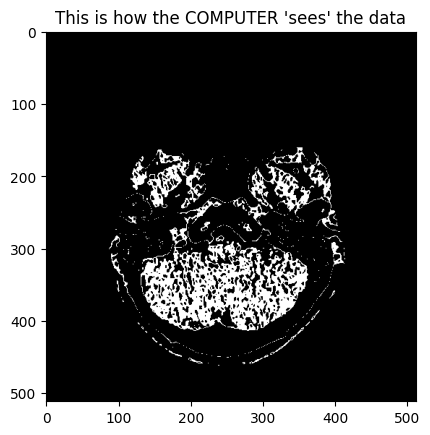

In [70]:
# Keep only the pixels that are likely to be contrast-filled vessels or bone
vessel_mask = (pixel_arrays[18] > 40) & (pixel_arrays[18] < 80)

# This creates a black and white image where only the vessels are white
plt.imshow(vessel_mask, cmap='gray')
plt.title("This is how the COMPUTER 'sees' the data")
plt.show()

In [21]:
!pip install monai numpy pydicom -q


[notice] A new release of pip available: 22.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import os
import torch
import numpy as np
import pydicom
from monai.transforms import (
    Compose,
    LoadImageD,        # This transform now handles adding the channel
    Lambdad,
    SpacingD,
    OrientationD,
    ScaleIntensityRangeD,
    ResizeD,
    EnsureTyped
)

# --- This function remains the same ---
def robust_hu_conversion(pixel_array, dicom_metadata):
    if 'RescaleSlope' in dicom_metadata and 'RescaleIntercept' in dicom_metadata:
        slope = float(dicom_metadata.RescaleSlope)
        intercept = float(dicom_metadata.RescaleIntercept)
        if pixel_array.min() < -500:
            return pixel_array.astype(np.float32)
        else:
            return (pixel_array * slope + intercept).astype(np.float32)
    else:
        return pixel_array.astype(np.float32)

def create_preprocessing_pipeline(
    target_spacing=(1.0, 1.0, 1.0),
    target_orientation="LPS",
    clip_min=-200,
    clip_max=1000,
    scale_min=0.0,
    scale_max=1.0,
    target_spatial_size=(256, 256, 128)
):
    """
    Creates a MONAI preprocessing pipeline with exposed parameters.
    """
    
    transforms = [
        # --- Step 1: Load Image & Add Channel ---
        # It now does two things:
        # 1. Loads all DICOM files from the list of paths.
        # 2. Stacks them into a 3D volume.
        # 3. Automatically adds a "channel" dimension at the beginning.
        # The output shape will be (1, H, W, D) - Channel, Height, Width, Depth
        LoadImageD(keys=["image"], image_only=False),
        
        # --- Step 2: Custom Robust HU Conversion ---
        # The 'Lambdad' transform is a wrapper that lets us apply our own custom
        # Python function to the data. It receives the image object from LoadImageD,
        # which contains both the pixel data (.get_array()) and the metadata (.meta).
        Lambdad(keys=["image"], func=lambda x: robust_hu_conversion(x.get_array(), x.meta)),
        
        # --- Step 3: Isotropic Resampling ---
        # This is SpacingD. It looks at the metadata to find the *current* voxel
        # spacing (e.g., 0.5mm, 0.5mm, 1.25mm) and uses interpolation to create a
        # *new* volume where the spacing is the `target_spacing` (e.g., 1mm, 1mm, 1mm).
        # This makes all voxels cubic, which is crucial for 3D CNNs.
        SpacingD(
            keys=["image"],
            pixdim=target_spacing,
            mode=("bilinear") # 'bilinear' is a good choice for continuous image data.
        ),
        
        # --- Step 4: Re-orientation ---
        # This is OrientationD. It reads the metadata to see how the patient is
        # currently oriented (e.g., lying on their side, feet-first). It then
        # rotates the entire 3D volume so it matches the standard `target_orientation`.
        # "LPS" means the final volume's axes are Left-to-Right, Posterior-to-Anterior,
        # and Superior-to-Inferior (Head).
        OrientationD(keys=["image"], axcodes=target_orientation),
        
        # --- Step 5: Intensity Clipping & Normalization ---
        # This is ScaleIntensityRangeD. It's a highly efficient way to do two things:
        # 1. `clip=True`: Any value below `a_min` (clip_min) is set to `a_min`.
        #    Any value above `a_max` (clip_max) is set to `a_max`.
        # 2. It then linearly scales this clipped range [a_min, a_max] to the
        #    new range [b_min, b_max] (scale_min, scale_max). This is normalization.
        ScaleIntensityRangeD(
            keys=["image"],
            a_min=clip_min,
            a_max=clip_max,
            b_min=scale_min,
            b_max=scale_max,
            clip=True,
        ),
        
        # --- Step 6: Resizing ---
        # After resampling and reorienting, our volumes will have different sizes.
        # A deep learning model requires all inputs to have the *exact same* size.
        # ResizeD forces every volume to conform to the `target_spatial_size`.
        # It will either pad (add empty space) or crop/interpolate to fit.
        ResizeD(
            keys=["image"],
            spatial_size=target_spatial_size,
            mode=("area")
        ),
        
        # --- Step 7: Ensure Correct Type ---
        # A final cleanup step to guarantee the output is a PyTorch tensor,
        # which is what models expect.
        EnsureTyped(keys=["image"], dtype=torch.float32),
    ]
    
    return Compose(transforms)

In [289]:
import os
import numpy as np
import pydicom

def process_np_scan(folder_path):
    pixarray =[]
    files =[]
    for x in os.listdir(folder_path):
        file = pydicom.dcmread(os.path.join(folder_path, x))
        files.append(file)
    files.sort(key=lambda x: int(x.InstanceNumber))
    pixarray = [robust_hu_conversion(file) for file in files]
    volume = np.stack(pixarray)
    print(volume.shape)
    return volume


In [164]:
vol = load_axial_volume(folder)

In [156]:
vol.shape

(276, 512, 512)

In [4]:
from view3d_data import view_3d_volume

In [22]:
import importlib
import view3d_data

importlib.reload(view3d_data)

<module 'view3d_data' from 'd:\\projects\\aneurysm\\view3d_data.py'>

In [157]:
win_vol = apply_window(vol, 800, 2000)

In [53]:
mask_vol = apply_mask(volume, 600, 800)

In [ ]:
view_3d_volume(vol, cmap='gray', title='3D Volume Viewer')

interactive(children=(IntSlider(value=138, description='slice_index', max=275), Output()), _dom_classes=('widg…

In [ ]:
sns.countplot(vol.flatten())

# preprocessing view

In [526]:
import numpy as np
import cv2

def maximum_intensity_projection(volume, axis=0):
    """
    Compute Maximum Intensity Projection (MIP) along the given axis.
    volume: 3D numpy array (slices, height, width)
    axis: 0 (axial), 1 (sagittal), 2 (coronal)
    """
    return np.max(volume, axis=axis)


def mra_like_enhancement(volume, low=100, high=400):
    """
    Enhance vessels like MRA by keeping HU in vessel range.
    """
    vessel_mask = (volume > low) & (volume < high)
    enhanced = np.zeros_like(volume)
    enhanced[vessel_mask] = volume[vessel_mask]
    return enhanced

def mip_all_axes(volume):
    """
    Generate MIP along all 3 axes for visualization.
    Returns dict with 'axial', 'sagittal', 'coronal' projections.
    """
    return {
        'axial': maximum_intensity_projection(volume, axis=0),
        'sagittal': maximum_intensity_projection(volume, axis=1),
        'coronal': maximum_intensity_projection(volume, axis=2)
    }

# Example usage
# volume is the np.array from your code
mip_ax = maximum_intensity_projection(vol, axis=0)
# bone_removed = bone_subtraction(volume)
vessel_enhanced = mra_like_enhancement(vol)
mip_all_ax = mip_all_axes(vol)

# # Show an example with OpenCV
# cv2.imshow("Axial MIP", cv2.convertScaleAbs(mip_ax, alpha=0.5))
# cv2.imshow("bone sub", cv2.convertScaleAbs(bone_removed, alpha=0.5))
# cv2.imshow("vessel_enhanced", cv2.convertScaleAbs(vessel_enhanced, alpha=0.5))

# cv2.waitKey(0)
# cv2.destroyAllWindows()


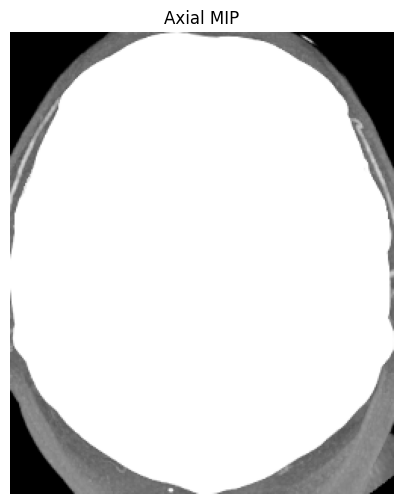

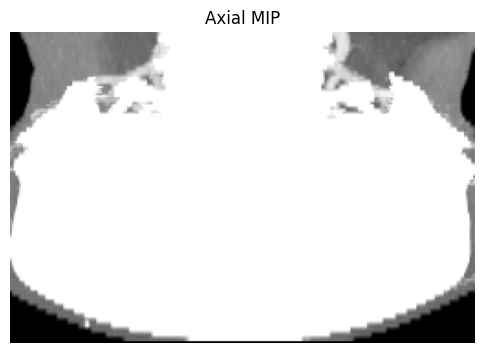

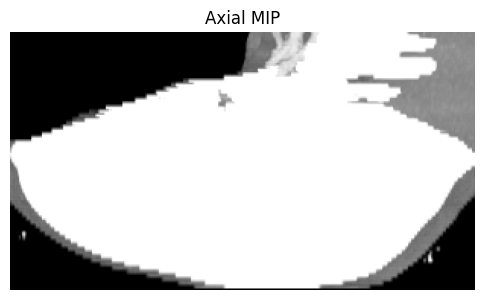

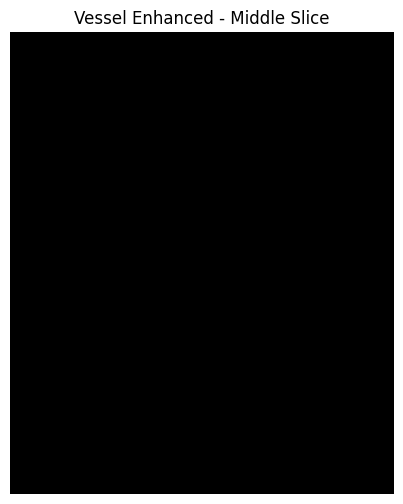

In [527]:
import matplotlib.pyplot as plt

def show_slice(img, title=""):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Show Axial MIP (2D projection)
show_slice(mip_all_ax['axial'], "Axial MIP")
show_slice(mip_all_ax['sagittal'], "Axial MIP")
show_slice(mip_all_ax['coronal'], "Axial MIP")


# Show a middle slice of bone subtracted volume
# mid_slice = bone_removed[bone_removed.shape[0] // 2]
# show_slice(mid_slice, "Bone Subtracted - Middle Slice")

# Show a middle slice of vessel enhancement
mid_slice_ve = vessel_enhanced[vessel_enhanced.shape[0] // 2]
show_slice(mid_slice_ve, "Vessel Enhanced - Middle Slice")


In [209]:
# volume
np.save('cta_test.npy',volume)

In [206]:
from skimage.filters import frangi
import numpy as np

# volume: 3D numpy (Z, Y, X) float, scaled to [0,1]
vesselness = frangi(volume, sigmas=range(1,6,1), black_ridges=False)
# save vesselness as float32 .npy or use as input channel


KeyboardInterrupt: 

# --

In [ ]:
sop = df_ct[df_ct['SOPInstanceUID'] == '1.2.826.0.1.3680043.8.498.10775329348174902199350466348663848346']

In [ ]:
f = r'rsna-intracranial-aneurysm-detection\series'
f_path = os.path.join(f, '1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317')


In [ ]:
import os
# import numpy as np
import pydicom

folder =f_path
for x in os.listdir(folder):
    file = pydicom.dcmread(os.path.join(folder, x))
    if (x == '1.2.826.0.1.3680043.8.498.10775329348174902199350466348663848346.dcm'):
        print(file.InstanceNumber)

163
(276, 512, 512)


In [175]:
local_csv = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train_localizers.csv')

In [ ]:
local_csv[local_csv['SeriesInstanceUID'] == '1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317']

,SeriesInstanceUID,SOPInstanceUID,coordinates,location
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,1.2.826.0.1.3680043.8.498.10775329348174902199...,"{'x': 258.3621186176837, 'y': 261.359900373599}",Other Posterior Circulation


In [ ]:
view_3d_volume(volume)

interactive(children=(IntSlider(value=138, description='slice_index', max=275), Output()), _dom_classes=('widg…

# preprocess pipeline

In [211]:
folder

'rsna-intracranial-aneurysm-detection\\series\\1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317'

In [497]:
import importlib
import preprocess_ct

importlib.reload(preprocess_ct)
from preprocess_ct import preprocess_cta_scan


In [282]:
df_ct[df_ct['SeriesInstanceUID'] =='1.2.826.0.1.3680043.8.498.69955588258737419513349554116268560350']

,Unnamed: 0.1,Unnamed: 0,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,PatientID,PatientAge_x,PatientSex_x,PatientWeight,PatientSize,...,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
749653,749653,749653,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10002383279970932718...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
749654,749654,749654,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10026178168280820086...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
749655,749655,749655,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10040500344072318612...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
749656,749656,749656,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10054073272307498929...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
749657,749657,749657,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10063885225094592632...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751089,751089,751089,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.99806660578920601690...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
751090,751090,751090,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.99809767470839306233...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
751091,751091,751091,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.99837424227807183792...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
751092,751092,751092,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.99932988149488993594...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [523]:
vol_old = process_np_scan(os.path.join(f,'1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557'))

(83, 512, 512)


In [524]:
view_3d_volume(vol_old)

interactive(children=(IntSlider(value=41, description='slice_index', max=82), Output()), _dom_classes=('widget…

In [346]:
folder

'rsna-intracranial-aneurysm-detection\\series\\1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317'

In [517]:
df_local = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train_localizers.csv')

In [525]:
df_local[df_local['SeriesInstanceUID'] == '1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557']

,SeriesInstanceUID,SOPInstanceUID,coordinates,location
4,1.2.826.0.1.3680043.8.498.10034081836061566510...,1.2.826.0.1.3680043.8.498.71237104731452368587...,"{'x': 249.86745590416498, 'y': 220.623044646393}",Anterior Communicating Artery


In [514]:
print(df_ct[df_ct['Aneurysm Present']==1].drop_duplicates(subset="SeriesInstanceUID").iloc[3]['SeriesInstanceUID'])
print(df_ct[df_ct['Aneurysm Present']==1].drop_duplicates(subset="SeriesInstanceUID").iloc[3]['SOPInstanceUID'])

df_ct[df_ct['Aneurysm Present']==1].drop_duplicates(subset="SeriesInstanceUID").iloc[3]


1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557
1.2.826.0.1.3680043.8.498.10304208137079626174560405694472881116


Unnamed: 0.1                                                                               3437
Unnamed: 0                                                                                 3437
StudyInstanceUID                              1.2.826.0.1.3680043.8.498.80807788490209335893...
SeriesInstanceUID                             1.2.826.0.1.3680043.8.498.10034081836061566510...
SOPInstanceUID                                1.2.826.0.1.3680043.8.498.10304208137079626174...
PatientID                                                                          4f045e1e-88e
PatientAge_x                                                                               055Y
PatientSex_x                                                                                  M
PatientWeight                                                                               NaN
PatientSize                                                                                 NaN
EthnicGroup                             

In [ ]:
t_f = pydicom.dcmread(r"D:\projects\aneurysm\rsna-intracranial-aneurysm-detection\series\1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557\1.2.826.0.1.3680043.8.498.71237104731452368587327801789352569583.dcm")

In [522]:
t_f.InstanceNumber

'47'

<Axes: ylabel='count'>

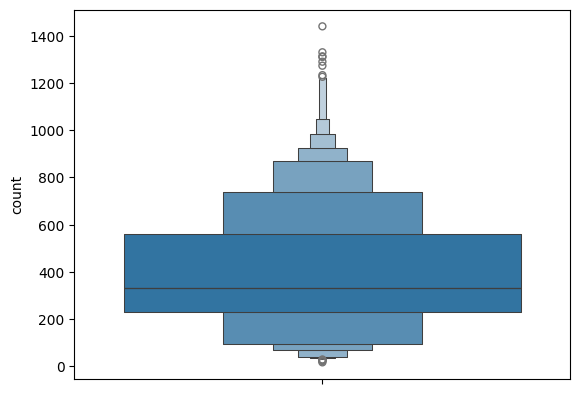

In [540]:
sns.boxenplot(df_ct['SeriesInstanceUID'].value_counts())


In [511]:
vol = preprocess_cta_scan(os.path.join(f,'1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557'))
vol.shape

(170, 306, 254)

In [ ]:
view_3d_volume(vol)

interactive(children=(IntSlider(value=85, description='slice_index', max=169), Output()), _dom_classes=('widge…

# deciding voxel size

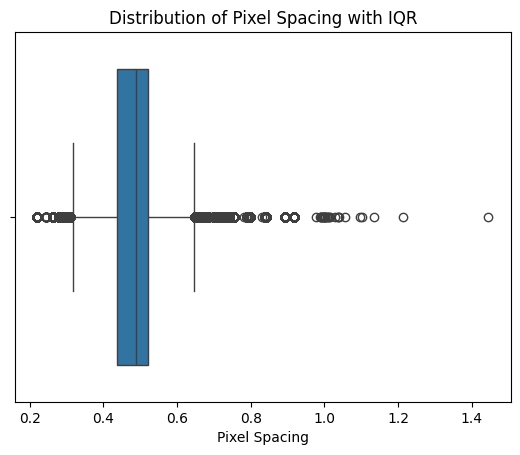

In [448]:
import ast

df_ct["PixelSpacing_val"] = df_ct["PixelSpacing"].apply(lambda x: float(ast.literal_eval(x)[0]))

sns.boxplot(x=df_ct["PixelSpacing_val"])
plt.xlabel("Pixel Spacing")
plt.title("Distribution of Pixel Spacing with IQR")
plt.show()


In [464]:
df_ct["PixelSpacing_val"].quantile(0.9)

np.float64(0.585938)

<Axes: >

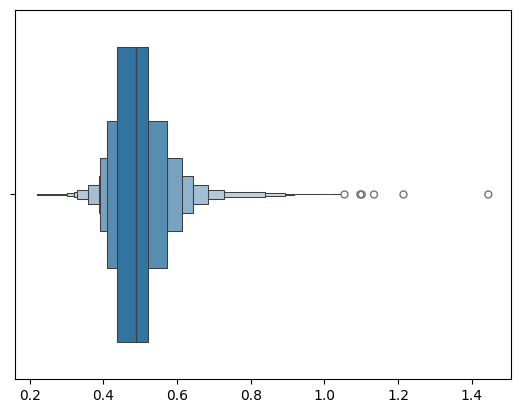

In [451]:
sns.boxenplot(x=values)


<Axes: xlabel='SliceThickness'>

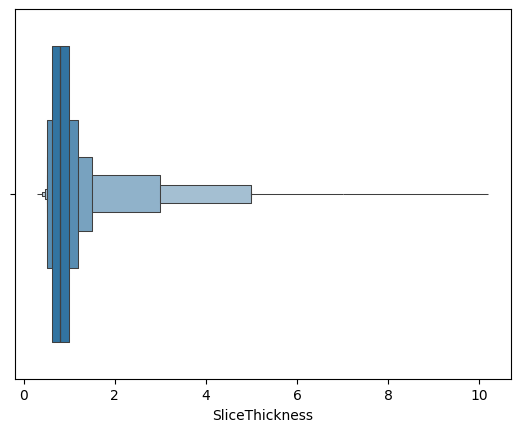

In [454]:
filtered = df_concat['SliceThickness']
filtered = filtered[(filtered <= 100) & (filtered.notna())]

sns.boxenplot(x=filtered)


<Axes: xlabel='SliceThickness'>

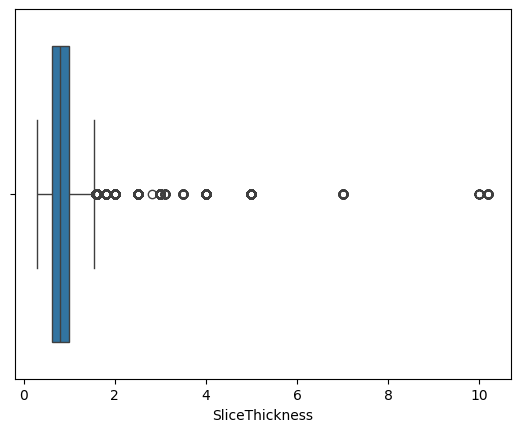

In [458]:
sns.boxplot(x=filtered)

In [462]:
filtered.quantile(0.9)

np.float64(1.2)

# finding neck

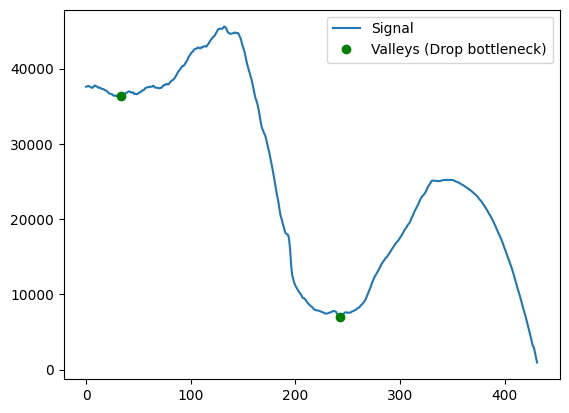

In [356]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Example signal (replace with your array)
# x = np.linspace(0, 20, 500)
# y = np.sin(x) + 0.2*x  # grows, drops, grows again (toy example)
# y = np.concatenate((np.array([100000]), vol, np.array([100000])))
y=vol
# Find peaks (local maxima)
peaks, _ = find_peaks(y, prominence=1000)  

# Find valleys (local minima) by inverting
valleys, _ = find_peaks(-y, prominence=1000)

# Plot
plt.plot(y, label="Signal")
# plt.plot(peaks, y[peaks], "ro", label="Peaks (Top bottleneck)")
plt.plot(valleys, y[valleys], "go", label="Valleys (Drop bottleneck)")
plt.legend()
plt.show()


In [320]:
np.array(range(0,1,20))

array([0])

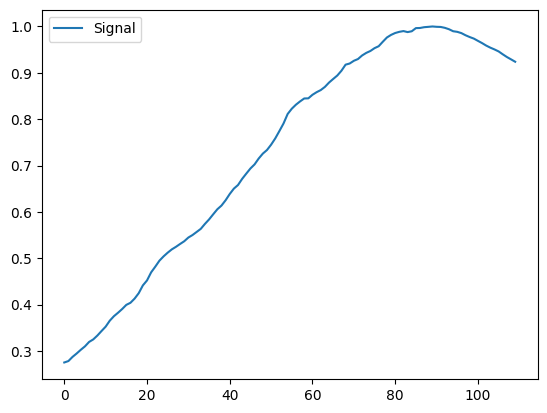

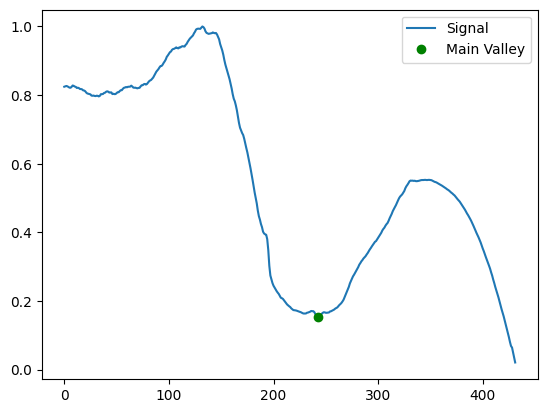

In [ ]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def find_bottlenecks(y):
    # Find peaks and valleys
    peaks, _ = find_peaks(y, prominence=0.005)
    valleys, _ = find_peaks(-y, prominence=0.005)

    peak_idx = None
    valley_idx = None

    if len(peaks) == 0:
        return None, None

    # Case 1: Only one peak
    if len(peaks) > 1:
        valley_idx = valleys[np.argmin(y[valleys])]


    return valley_idx

# Example usage
# x = np.linspace(0, 10, 500)
# y = np.sin(x) + 0.1*x + np.where(x>6, -2, 0)  # custom shape
y=vol/np.max(vol)

peak, valley = find_bottlenecks(y)

plt.plot(y, label="Signal")
if peak is not None:
    plt.plot(peak, y[peak], "ro", label="Main Peak")
if valley is not None:
    plt.plot(valley, y[valley], "go", label="Main Valley")
plt.legend()
plt.show()

y=vol2/np.max(vol2)

peak, valley = find_bottlenecks(y)

plt.plot(y, label="Signal")
if peak is not None:
    plt.plot(peak, y[peak], "ro", label="Main Peak")
if valley is not None:
    plt.plot(valley, y[valley], "go", label="Main Valley")
plt.legend()
plt.show()


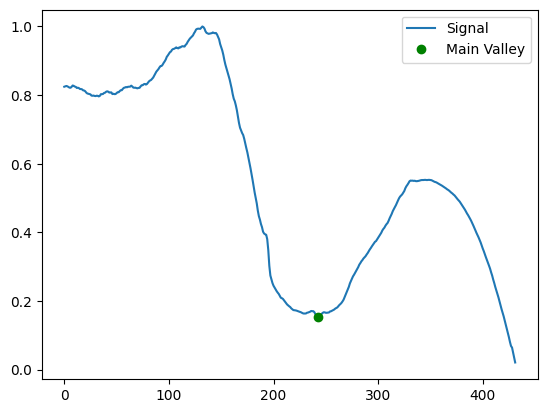

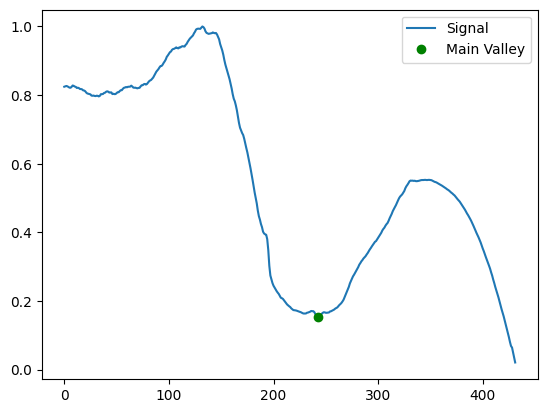

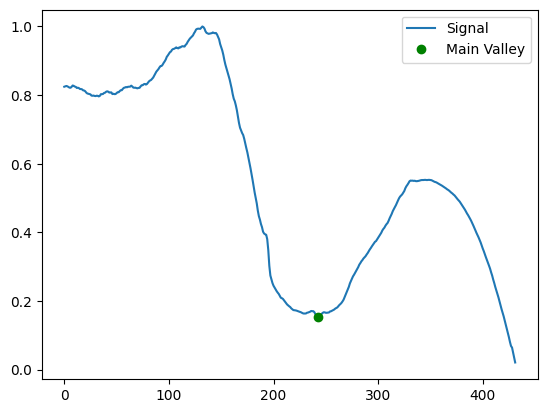

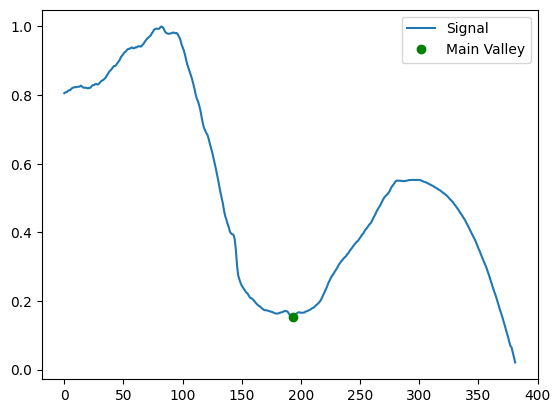

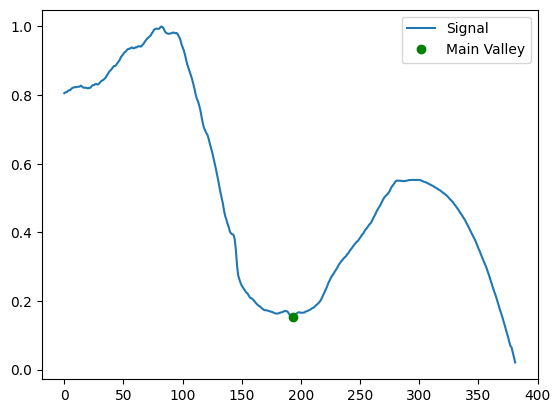

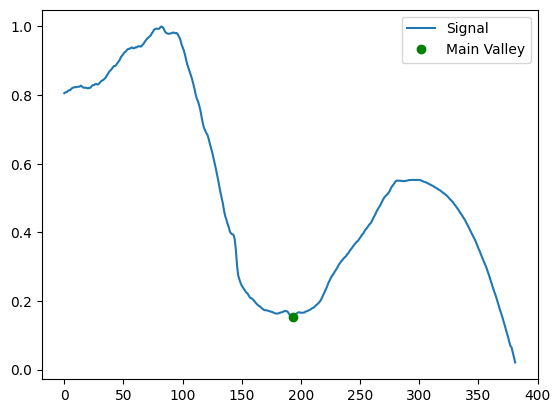

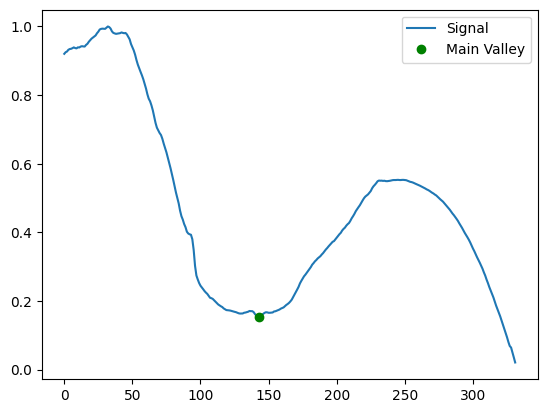

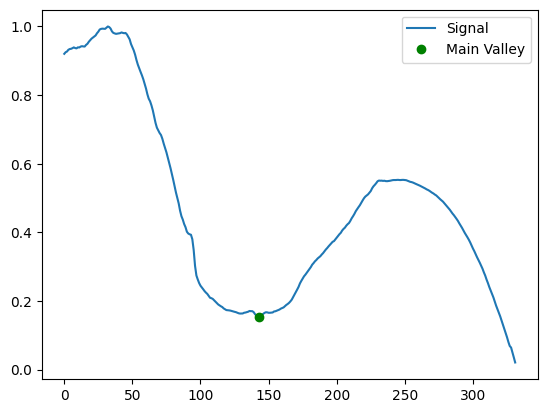

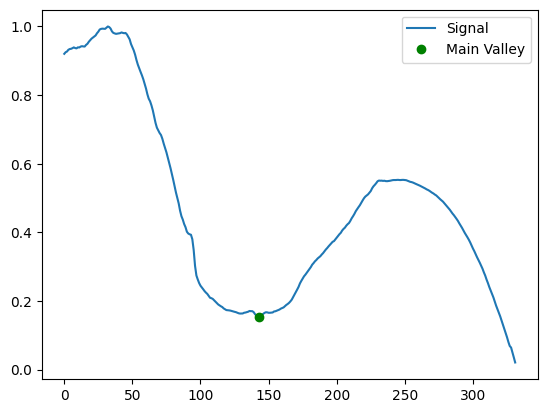

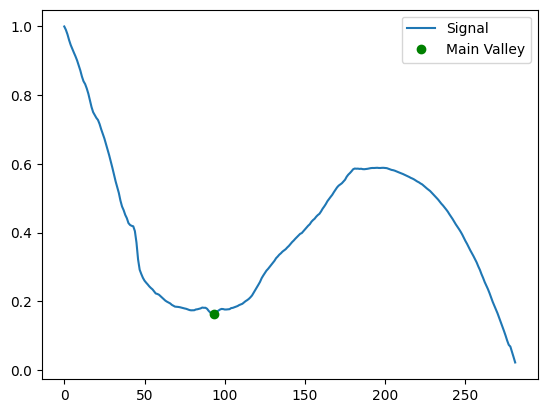

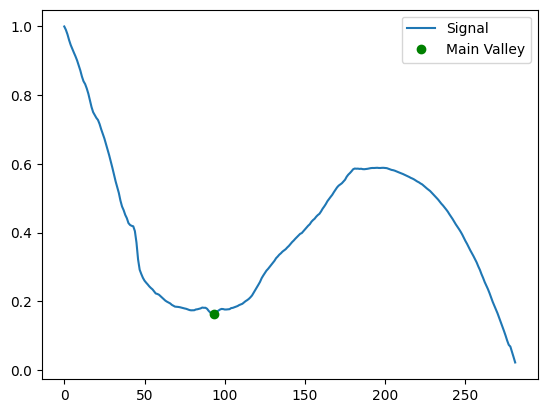

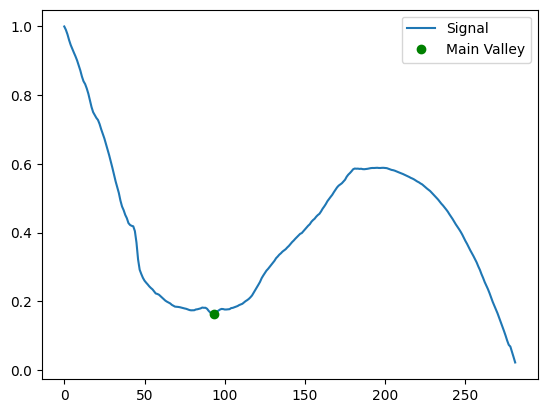

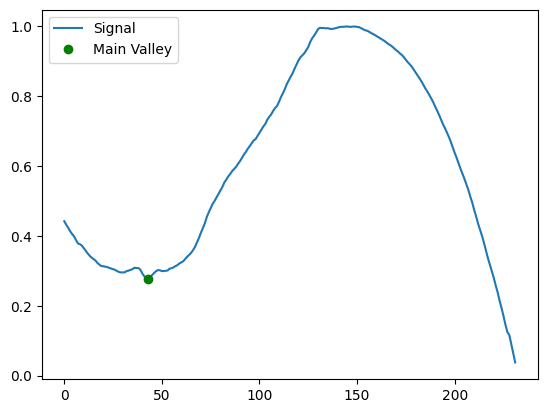

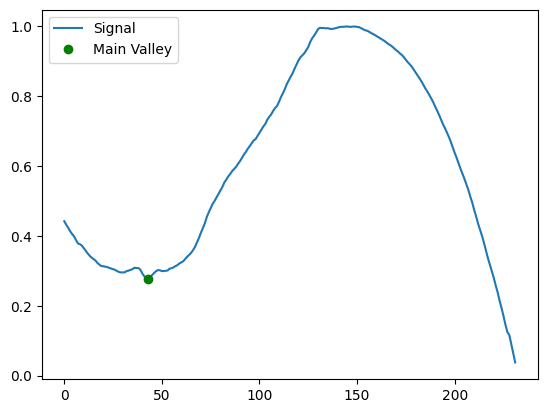

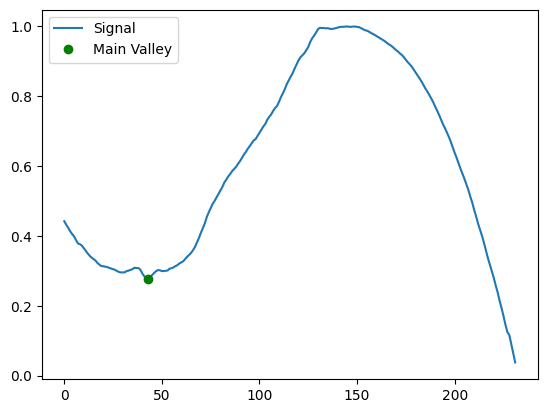

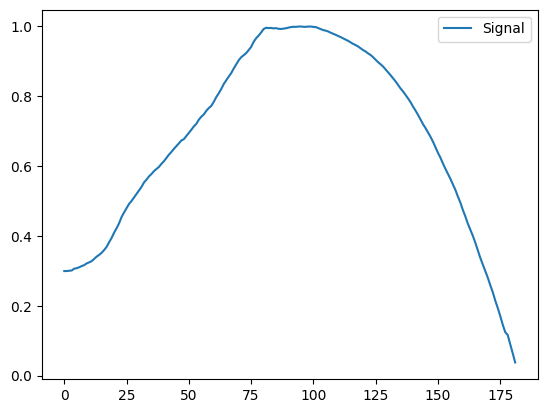

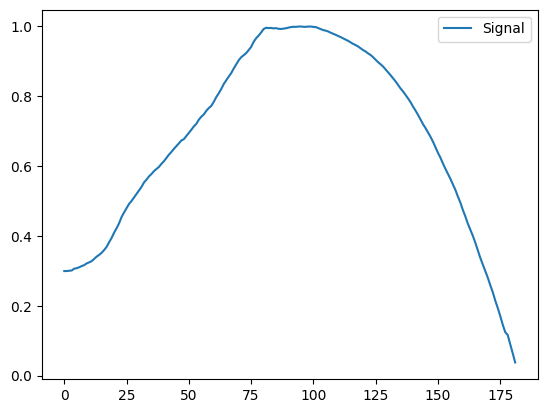

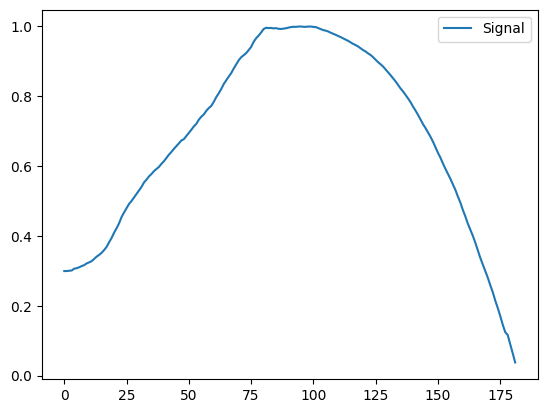

In [376]:
for x in range(0,300,50):
    for y in range(432,310,-50):
        y=vol2[x:]/np.max(vol2[x:])

        peak, valley = find_bottlenecks(y)

        plt.plot(y, label="Signal")
        if peak is not None:
            plt.plot(peak, y[peak], "ro", label="Main Peak")
        if valley is not None:
            plt.plot(valley, y[valley], "go", label="Main Valley")
        plt.legend()
        plt.show()

In [410]:
def find_neck_cutoff(mask: np.ndarray) -> int:
    areas = np.sum(mask, axis=(1, 2))
    areas = (areas - areas.min()) / (areas.max() - areas.min())
    peaks, _ = find_peaks(areas, prominence=0.005)
    valleys, _ = find_peaks(-areas, prominence=0.005)

    valley_idx = None

    if len(peaks) == 0:
        return None, None

    if len(peaks) > 1:
        valley_idx = valleys[np.argmin(areas[valleys])]


    return valley_idx

neck_idx = find_neck_cutoff(vol)


In [407]:
view_3d_volume(vol)

interactive(children=(IntSlider(value=138, description='slice_index', max=275), Output()), _dom_classes=('widg…

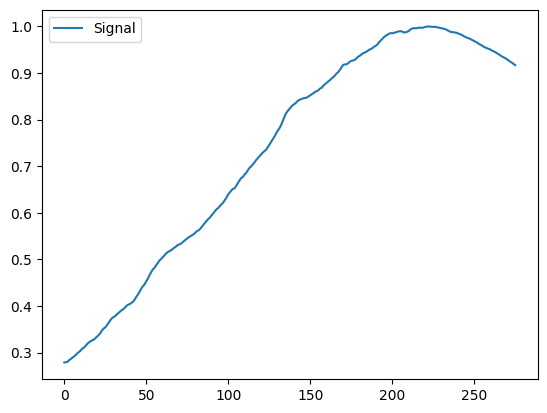

In [ ]:
y=np.sum(vol, axis=(1, 2))/np.max(np.sum(vol, axis=(1, 2)))

# peak, valley = find_bottlenecks(y)

plt.plot(y, label="Signal")
# if peak is not None:
#     plt.plot(peak, y[peak], "ro", label="Main Peak")
if neck_idx is not None:
    plt.plot(neck_idx, y[neck_idx], "go", label="Main Valley")
plt.legend()
plt.show()

# mr minimal

In [531]:
f

'rsna-intracranial-aneurysm-detection\\series'

In [532]:
mr_path = os.path.join(f,df_mr['SeriesInstanceUID'].iloc[0])

In [533]:
mr_sc = process_np_scan(mr_path)

(188, 512, 512)


In [535]:
mr_sc_ctprep = preprocess_cta_scan(mr_path)

In [536]:
view_3d_volume(mr_sc_ctprep)

interactive(children=(IntSlider(value=7, description='slice_index', max=14), Output()), _dom_classes=('widget-…

In [ ]:
view_3d_volume(mr_sc)

interactive(children=(IntSlider(value=94, description='slice_index', max=187), Output()), _dom_classes=('widge…

# multiprocess cta rpocees

In [ ]:
# Save this as run_preprocessing_v2.py
import os
import pandas as pd
import SimpleITK as sitk
import numpy as np
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

# IMPORTANT: Make sure your preprocessing script is in the same directory
from preprocess_ct import preprocess_cta_scan

# --- CONFIGURATION ---
BASE_PATH = r'rsna-intracranial-aneurysm-detection\series'
OUTPUT_DIR = r'processed_data'
CSV_LOG_PATH = os.path.join(OUTPUT_DIR, 'preprocessing_log.csv')

# Use one less than your total cores to keep your system responsive
NUM_PROCESSES = max(1, cpu_count() - 4)

def process_and_save_scan(args):
    """
    A wrapper function for a single scan. Takes a tuple of arguments.
    This function will be called by each parallel process.
    """
    series_uid, base_path, output_dir = args
    
    folder_path = os.path.join(base_path, series_uid)
    output_path = os.path.join(output_dir, f"{series_uid}.nii.gz")
    
    if os.path.exists(output_path):
        return {
            'SeriesInstanceUID': series_uid, 'status': 'Skipped',
            'shape_z_y_x': None, 'error': 'File already exists'
        }
        
    try:
        processed_array, final_spacing_zyx = preprocess_cta_scan(folder_path)
        
        if processed_array.size == 0:
             raise ValueError("Preprocessing returned an empty array.")

        sitk_image = sitk.GetImageFromArray(processed_array)
        sitk_image.SetSpacing(final_spacing_zyx[::-1]) # (x, y, z) order
        sitk.WriteImage(sitk_image, output_path)
        
        return {
            'SeriesInstanceUID': series_uid, 'status': 'Success',
            'shape_z_y_x': processed_array.shape, 'error': None
        }

    except Exception as e:
        return {
            'SeriesInstanceUID': series_uid, 'status': 'Failed',
            'shape_z_y_x': None, 'error': str(e)
        }

# This guard is ESSENTIAL for multiprocessing to work correctly
if __name__ == '__main__':
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    try:
        df_orig_train = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')
        uids_to_process = df_orig_train[df_orig_train['Modality'] == 'CTA']['SeriesInstanceUID'].tolist()[:2]
        print(f"Found {len(uids_to_process)} CTA SeriesInstanceUIDs to process.")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        exit()
    
    tasks = [(uid, BASE_PATH, OUTPUT_DIR) for uid in uids_to_process]

    print(f"Starting preprocessing with {NUM_PROCESSES} parallel processes...")

    results = []
    # This is the robust way to run multiprocessing with a progress bar
    with Pool(processes=NUM_PROCESSES) as pool:
        for result in tqdm(pool.imap_unordered(process_and_save_scan, tasks), total=len(tasks)):
            results.append(result)

    print("\nPreprocessing complete. Generating log file...")
    
    results_df = pd.DataFrame(results)
    
    # Sort by UID to have a consistent log file order
    results_df = results_df.sort_values(by='SeriesInstanceUID').reset_index(drop=True)
    results_df = results_df[['SeriesInstanceUID', 'status', 'shape_z_y_x', 'error']]
    results_df.to_csv(CSV_LOG_PATH, index=False)

    print(f"Log file saved to: {CSV_LOG_PATH}")
    
    status_counts = results_df['status'].value_counts()
    print("\n--- Summary ---")
    print(status_counts)
    print("-----------------")

Found 2 CTA SeriesInstanceUIDs to process.
Starting preprocessing with 12 parallel processes...


  0%|          | 0/2 [00:00<?, ?it/s]

In [5]:
df_orig_train[df_orig_train['Modality'] == 'CTA']['SeriesInstanceUID']

2       1.2.826.0.1.3680043.8.498.10005158603912009425...
5       1.2.826.0.1.3680043.8.498.10014757658335054766...
6       1.2.826.0.1.3680043.8.498.10021411248005513321...
8       1.2.826.0.1.3680043.8.498.10022796280698534221...
10      1.2.826.0.1.3680043.8.498.10030095840917973694...
                              ...                        
4396    1.2.826.0.1.3680043.8.498.99887675554378211308...
4397    1.2.826.0.1.3680043.8.498.99892390884723813599...
4399    1.2.826.0.1.3680043.8.498.99895756899933461331...
4402    1.2.826.0.1.3680043.8.498.99953513260518059135...
4404    1.2.826.0.1.3680043.8.498.99985209798463601651...
Name: SeriesInstanceUID, Length: 1857, dtype: object

In [1]:
tasks[0]

NameError: name 'tasks' is not defined

In [3]:
import SimpleITK as sitk

# Load the NIfTI file
image = sitk.ReadImage(r"processed_data\1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317.nii.gz")

# Get numpy array from image
import numpy as np
image_array = sitk.GetArrayFromImage(image)  # shape: [slices, height, width]

print("Image size:", image.GetSize())        # (x, y, z)
print("Image spacing:", image.GetSpacing())  # voxel spacing
print("Array shape:", image_array.shape)     # (z, y, x)


Image size: (253, 299, 86)
Image spacing: (1.2000000476837158, 0.5799999833106995, 0.5799999833106995)
Array shape: (86, 299, 253)
